# Семинар 2. Исследование методов линейной регрессии

#### Критерий оценивания:
#### Пункт 14: максимум 0,5 балла
#### Пункт 15: максимум 0,5 балла

#### Итого за работу: максимум 1 балл
#### P.S. пункты 14 и 15 без пунктов 1-13 не засчитываются, ответы на вопросы из ИИ не засчитываются

1. Загрузите датасет и выведите на экран первые несколько строк

In [38]:
from pathlib import Path
from typing import Literal, NamedTuple, Self

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.typing import NDArray
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

Array = NDArray[np.float64]

DATA_PATH = Path("auto_dataset.csv")

data = pd.read_csv(DATA_PATH)
data.head()

,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000


2. Разбейте выборку на признаки и ответы. Закодируйте категориальные признаки.

In [39]:
TARGET = "price"
CAT_FEATURES = ["brand", "model", "vehicleType", "gearbox", "fuelType", "notRepairedDamage"]
NUM_FEATURES = ["powerPS", "kilometer", "autoAgeMonths"]


class Dataset(NamedTuple):
    """Готовые матрицы признаков и векторы ответов; первый столбец X — единицы под свободный член."""

    X_train: Array
    y_train: Array
    X_val: Array
    y_val: Array
    X_test: Array
    y_test: Array


def add_bias(X: Array) -> Array:
    """Приписывает слева столбец единиц, чтобы свободный член вошёл в вектор весов."""
    return np.c_[np.ones(X.shape[0], dtype=np.float64), X]


def build_dataset(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    *,
    cat_features: list[str],
    num_features: list[str],
    target: str,
) -> tuple[Dataset, ColumnTransformer]:
    """Кодирует признаки: числовые — StandardScaler, категориальные — one-hot.

    Препроцессинг обучается только на train (fit_transform), val и test лишь
    преобразуются (transform) — статистики этих выборок в кодировщик не попадают.
    Категории, которых не было в train, дают нулевую строку в своём one-hot блоке
    (handle_unknown="ignore"), а не ошибку.
    """
    encoder = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_features),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
        ],
    )
    dataset = Dataset(
        X_train=add_bias(np.asarray(encoder.fit_transform(train_df), dtype=np.float64)),
        y_train=np.asarray(train_df[target], dtype=np.float64),
        X_val=add_bias(np.asarray(encoder.transform(val_df), dtype=np.float64)),
        y_val=np.asarray(val_df[target], dtype=np.float64),
        X_test=add_bias(np.asarray(encoder.transform(test_df), dtype=np.float64)),
        y_test=np.asarray(test_df[target], dtype=np.float64),
    )
    return dataset, encoder

3. Разбейте датасет на train val test в отношении 8:1:1

In [40]:
SPLIT_SEED = 67


def split_data(
    data: pd.DataFrame,
    *,
    train_size: float = 0.8,
    val_size: float = 0.1,
    random_state: int = SPLIT_SEED,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Случайно делит данные на train/val/test (по умолчанию 8:1:1) с фиксированным seed."""
    train_df, rest_df = train_test_split(data, train_size=train_size, random_state=random_state)
    val_df, test_df = train_test_split(rest_df, train_size=val_size / (1.0 - train_size), random_state=random_state)
    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


train_df, val_df, test_df = split_data(data)
dataset, encoder = build_dataset(
    train_df,
    val_df,
    test_df,
    cat_features=CAT_FEATURES,
    num_features=NUM_FEATURES,
    target=TARGET,
)

# mean(y), var(y) и mean(y^2) печатаем не для красоты: MSE измеряется в (рублях цены)^2 и
# пропорционален разбросу ответов внутри выборки, поэтому уровни Loss_train и Loss_val
# сравнимы только с поправкой на эти числа (см. анализ после пункта 14).
print("столбцов после кодирования:", len(encoder.get_feature_names_out()), "+ 1 (bias)")
for name, X, y in (
    ("train", dataset.X_train, dataset.y_train),
    ("val  ", dataset.X_val, dataset.y_val),
    ("test ", dataset.X_test, dataset.y_test),
):
    print(
        f"{name}: X={X.shape} y={y.shape} "
        f"mean(y)={y.mean():8.1f} var(y)={y.var():.2f} mean(y^2)={np.mean(y**2):.2f} max(y)={y.max():8.1f}"
    )

столбцов после кодирования: 199 + 1 (bias)
train: X=(800, 200) y=(800,) mean(y)=  7190.9 var(y)=66142744.80 mean(y^2)=117852075.24 max(y)= 51000.0
val  : X=(100, 200) y=(100,) mean(y)=  5863.5 var(y)=21687438.89 mean(y^2)=56068540.22 max(y)= 16500.0
test : X=(100, 200) y=(100,) mean(y)=  7260.7 var(y)=60128584.74 mean(y^2)=112846058.80 max(y)= 56900.0


### Каркас эксперимента (пункты 4–13)

Дальше все пункты используют один и тот же набор функций, разделённый по ответственности:

* **модель** — `predict` (ŷ = X·w) и `mse_gradient` (градиент MSE);
* **метрики** — `mse`, `r2`, `evaluate`; считают качество по готовым весам и не знают про обучение;
* **обучение** — `BaseLinearDescent`: общий цикл, расписание шага, история лоссов, лучшая по `Loss_val` итерация; конкретный метод задаёт только `_step`;
* **эксперимент** — `tune_step` (перебор шага, выбор лучшего **по `Loss_val`**) и `print_best` (отчёт, единственное обращение к test);
* **графики** — `plot_experiment`; в выборе гиперпараметров не участвует.

In [41]:
def predict(X: Array, w: Array) -> Array:
    """Линейная регрессия: ŷ = X @ w. Свободный член — вес при столбце единиц."""
    return X @ w


def mse_gradient(X: Array, y: Array, w: Array) -> Array:
    """∇_w MSE(w) = (2/n) · Xᵀ (X·w − y), где n — число строк переданного X.

    Мини-батчевым методам передаём подматрицу: нормировка сама подстраивается под размер батча.
    """
    return 2.0 / X.shape[0] * X.T @ (predict(X, w) - y)

In [42]:
def mse(y_true: Array, y_pred: Array) -> float:
    """MSE = (1/n) · Σ (y_i − ŷ_i)².

    Считаем через numpy, не через sklearn: `_record` вызывает это на каждой итерации,
    и sklearn.metrics на 5000 шагах заметно тормозит Adam/VGD в ноутбуке.
    """
    residual = y_true - y_pred
    return float(np.dot(residual, residual) / y_true.shape[0])


def r2(y_true: Array, y_pred: Array) -> float:
    """R² = 1 − Σ (y_i − ŷ_i)² / Σ (y_i − mean(y))²; mean(y) — среднее той же выборки, что и y."""
    return float(r2_score(y_true, y_pred))


def loss_on(X: Array, y: Array, w: Array) -> float:
    """MSE весов w на выборке (X, y); inf, если предсказания переполнились (метод разошёлся)."""
    pred = predict(X, w)
    return mse(y, pred) if np.isfinite(pred).all() else float("inf")


def evaluate(X: Array, y: Array, w: Array) -> tuple[float, float]:
    """(MSE, R²) весов w на выборке (X, y).

    У разошедшихся методов возвращаем (inf, -inf), а не NaN: такие точки видно в таблице,
    но они не ломают сравнение шагов и выпадают из графиков по маске isfinite.
    """
    pred = predict(X, w)
    if not np.isfinite(pred).all():
        return float("inf"), float("-inf")
    return mse(y, pred), r2(y, pred)

In [43]:
STEP_GRID = np.logspace(-5, 0, 6, dtype=np.float64)
MAX_ITER = 5_000
MODEL_SEED = 42
DECAY_S0 = 1.0
DECAY_P = 0.5

Schedule = Literal["const", "time_decay"]


class BaseLinearDescent:
    """Общий цикл градиентного обучения линейной регрессии.

    Веса стартуют с нуля; за одну итерацию делается один шаг `_step` (его задаёт наследник).
    После каждого шага пишем MSE на train и на val: train — то, что минимизируем,
    val — только наблюдение, в градиент он не входит. Историю индексируем номером
    итерации: элемент 0 — веса до первого шага, последний элемент соответствует `weights_`.
    Заодно запоминаем итерацию с минимальным Loss_val (`best_iteration_`, `best_weights_`) —
    это и есть выбор числа итераций по валидации.
    """

    def __init__(
        self,
        step: float,
        *,
        schedule: Schedule = "const",
        s0: float = DECAY_S0,
        p: float = DECAY_P,
        max_iter: int = MAX_ITER,
        random_state: int = MODEL_SEED,
    ) -> None:
        if schedule not in ("const", "time_decay"):
            raise ValueError(f"неизвестное расписание шага: {schedule!r}")
        self.step = step
        self.schedule = schedule
        self.s0 = s0
        self.p = p
        self.max_iter = max_iter
        self.random_state = random_state
        self.weights_: Array | None = None
        self.best_weights_: Array | None = None
        self.best_val_loss_ = float("inf")
        self.best_iteration_ = 0
        self.n_iter_ = 0
        self.train_loss_history: list[float] = []
        self.val_loss_history: list[float] = []

    @property
    def weights(self) -> Array:
        """Веса после обучения (последняя итерация)."""
        if self.weights_ is None:
            raise RuntimeError("Модель ещё не обучена.")
        return self.weights_

    @property
    def best_weights(self) -> Array:
        """Веса итерации с минимальным Loss_val — early stopping уже после обучения."""
        if self.best_weights_ is None:
            raise RuntimeError("Модель ещё не обучена.")
        return self.best_weights_

    def _lr(self, k: int) -> float:
        """Шаг на итерации k: const → λ, time_decay → λ · (s0 / (s0 + k))^p."""
        if self.schedule == "const":
            return float(self.step)
        return float(self.step * (self.s0 / (self.s0 + k)) ** self.p)

    def step_label(self) -> str:
        """Как шаг подписывается в таблицах и на графиках."""
        step = f"{self.step:.10f}".rstrip("0").rstrip(".")
        if self.schedule == "const":
            return step
        return f"TimeDecayLR(λ={step})"

    def _init_state(self, n_samples: int, n_features: int) -> None:
        """Сбрасывает внутреннее состояние метода (импульс, моменты Adam, таблица SAG)."""

    def _step(self, X: Array, y: Array, w: Array, k: int, rng: np.random.Generator) -> Array:
        """Один шаг метода: возвращает новые веса."""
        raise NotImplementedError

    def _record(self, X: Array, y: Array, X_val: Array, y_val: Array, w: Array, iteration: int) -> float:
        """Пишет MSE на train и val и обновляет лучшую по val итерацию. Возвращает Loss_train."""
        train_loss = loss_on(X, y, w)
        val_loss = loss_on(X_val, y_val, w)
        self.train_loss_history.append(train_loss)
        self.val_loss_history.append(val_loss)
        if val_loss < self.best_val_loss_:
            self.best_val_loss_ = val_loss
            self.best_iteration_ = iteration
            self.best_weights_ = w.copy()
        return train_loss

    def fit(self, X: Array, y: Array, X_val: Array, y_val: Array) -> Self:
        """Обучает веса на (X, y); (X_val, y_val) нужны только для истории и лучшей итерации."""
        self.weights_ = None
        self.best_weights_ = None
        self.best_val_loss_ = float("inf")
        self.best_iteration_ = 0
        self.n_iter_ = 0
        self.train_loss_history = []
        self.val_loss_history = []

        w = np.zeros(X.shape[1], dtype=np.float64)
        self._init_state(n_samples=X.shape[0], n_features=X.shape[1])
        rng = np.random.default_rng(self.random_state)
        self._record(X, y, X_val, y_val, w, iteration=0)
        for k in range(self.max_iter):
            w = self._step(X, y, w, k, rng)
            self.n_iter_ = k + 1
            if not np.isfinite(w).all():  # веса ушли в inf/nan — дальше считать нечего
                break
            if not np.isfinite(self._record(X, y, X_val, y_val, w, iteration=k + 1)):
                break
        self.weights_ = w
        return self

In [44]:
def tune_step(
    descent_cls: type[BaseLinearDescent],
    dataset: Dataset,
    *,
    schedule: Schedule,
    step_name: str,
    step_grid: Array = STEP_GRID,
) -> tuple[pd.DataFrame, BaseLinearDescent]:
    """Перебирает шаг по сетке: обучение на train, выбор лучшего шага по минимуму Loss_val.

    Test здесь не используется — он нужен только для финальной оценки уже выбранной модели.
    np.seterr глушит предупреждения о переполнении: у больших шагов метод расходится,
    и это ожидаемая часть эксперимента. После каждого шага сетки печатаем Loss_val,
    чтобы ячейка не выглядела зависшей на Adam (6×5000 итераций без вывода).
    """
    models: list[BaseLinearDescent] = []
    rows: list[dict[str, float]] = []
    old_err = np.seterr(over="ignore", invalid="ignore")
    try:
        for step in step_grid:
            model = descent_cls(float(step), schedule=schedule).fit(
                dataset.X_train,
                dataset.y_train,
                dataset.X_val,
                dataset.y_val,
            )
            loss_train, r2_train = evaluate(dataset.X_train, dataset.y_train, model.weights)
            loss_val, r2_val = evaluate(dataset.X_val, dataset.y_val, model.weights)
            models.append(model)
            rows.append(
                {
                    step_name: model.step,
                    "loss_train": loss_train,
                    "r2_train": r2_train,
                    "loss_val": loss_val,
                    "r2_val": r2_val,
                    "n_iter": model.n_iter_,
                    "best_iter_val": model.best_iteration_,
                }
            )
            print(
                f"  {step_name}={float(step):g}: Loss_val={loss_val:.3g}, R^2_val={r2_val:.3f}, iter={model.n_iter_}",
                flush=True,
            )
    finally:
        np.seterr(**old_err)
    table = pd.DataFrame(rows)
    return table, models[int(table["loss_val"].idxmin())]


def print_best(
    name: str,
    table: pd.DataFrame,
    model: BaseLinearDescent,
    step_name: str,
    dataset: Dataset,
) -> None:
    """Печатает метрики выбранного по Loss_val шага и единственную оценку на test."""
    best = table.loc[table["loss_val"].idxmin()]
    loss_test, r2_test = evaluate(dataset.X_test, dataset.y_test, model.weights)
    print(name)
    print(f"  лучший {step_name}: {best[step_name]:.5f}".rstrip("0").rstrip("."))
    print(f"  Loss_train: {best['loss_train']:.2f}")
    print(f"  R^2_train:  {best['r2_train']:.2f}")
    print(f"  Loss_val:   {best['loss_val']:.2f}")
    print(f"  R^2_val:    {best['r2_val']:.2f}")
    print(f"  Loss_test:  {loss_test:.2f}")
    print(f"  R^2_test:   {r2_test:.2f}")
    print(f"  итераций:   {model.n_iter_} (минимум Loss_val на итерации {model.best_iteration_})")

In [45]:
def plot_experiment(
    table: pd.DataFrame,
    model: BaseLinearDescent,
    step_name: str,
    title: str,
) -> None:
    """Три панели: Loss(шаг), R²(шаг) и сходимость при лучшем шаге.

    Loss_train и Loss_val считаются на разных выборках с разным разбросом цены,
    поэтому по этим кривым сравнивают форму (какой шаг лучше), а не уровни между собой;
    для сравнения выборок между собой есть R², он нормирован на разброс ответов.
    """
    x = table[step_name].to_numpy(dtype=np.float64)
    best_x = float(x[int(table["loss_val"].idxmin())])

    fig = plt.figure(figsize=(11, 8))
    ax_loss = fig.add_subplot(2, 2, 1)
    ax_r2 = fig.add_subplot(2, 2, 2)
    ax_hist = fig.add_subplot(2, 1, 2)

    for column, label in (("loss_train", "Loss_train"), ("loss_val", "Loss_val")):
        y = table[column].to_numpy(dtype=np.float64)
        mask = np.isfinite(y)
        ax_loss.plot(x[mask], y[mask], marker="o", label=label)
    ax_loss.axvline(best_x, color="black", linestyle="--", linewidth=1, label=f"лучший {step_name} (по Loss_val)")
    ax_loss.set_xscale("log")
    ax_loss.set_yscale("log")
    ax_loss.set_xlabel(step_name)
    ax_loss.set_ylabel("MSE")
    ax_loss.set_title("Loss от шага")
    ax_loss.grid(True, which="both")
    ax_loss.legend()

    for column, label, style in (("r2_train", "R²_train", "-"), ("r2_val", "R²_val", "--")):
        y = table[column].to_numpy(dtype=np.float64)
        mask = np.isfinite(y)
        ax_r2.plot(x[mask], y[mask], marker="o", linestyle=style, label=label)
    ax_r2.axvline(best_x, color="black", linestyle="--", linewidth=1)
    ax_r2.set_xscale("log")
    ax_r2.set_xlabel(step_name)
    ax_r2.set_ylabel("R²")
    ax_r2.set_title("R² от шага")
    ax_r2.grid(True, which="both")
    ax_r2.legend()

    ax_hist.plot(model.train_loss_history, label="Loss_train")
    ax_hist.plot(model.val_loss_history, label="Loss_val")
    ax_hist.axvline(
        model.best_iteration_,
        color="black",
        linestyle="--",
        linewidth=1,
        label=f"минимум Loss_val: итерация {model.best_iteration_}",
    )
    ax_hist.set_yscale("log")
    ax_hist.set_xlabel("итерация")
    ax_hist.set_ylabel("MSE")
    ax_hist.set_title(f"сходимость при лучшем шаге ({model.step_label()})")
    ax_hist.grid(True)
    ax_hist.legend()

    fig.suptitle(title)
    fig.tight_layout()

4. Исследуйте VGD с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите VGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте VGD на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте VGD c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

  n=1e-05: Loss_val=3.31e+07, R^2_val=-0.527, iter=5000
  n=0.0001: Loss_val=8.81e+06, R^2_val=0.594, iter=5000
  n=0.001: Loss_val=1.17e+07, R^2_val=0.458, iter=5000
  n=0.01: Loss_val=1.26e+07, R^2_val=0.420, iter=5000
  n=0.1: Loss_val=1.72e+07, R^2_val=0.209, iter=5000
  n=1: Loss_val=inf, R^2_val=-inf, iter=197
VGD, постоянный шаг
  лучший n: 0.0001
  Loss_train: 26390034.35
  R^2_train:  0.60
  Loss_val:   8807967.36
  R^2_val:    0.59
  Loss_test:  22096696.75
  R^2_test:   0.63
  итераций:   5000 (минимум Loss_val на итерации 4256)


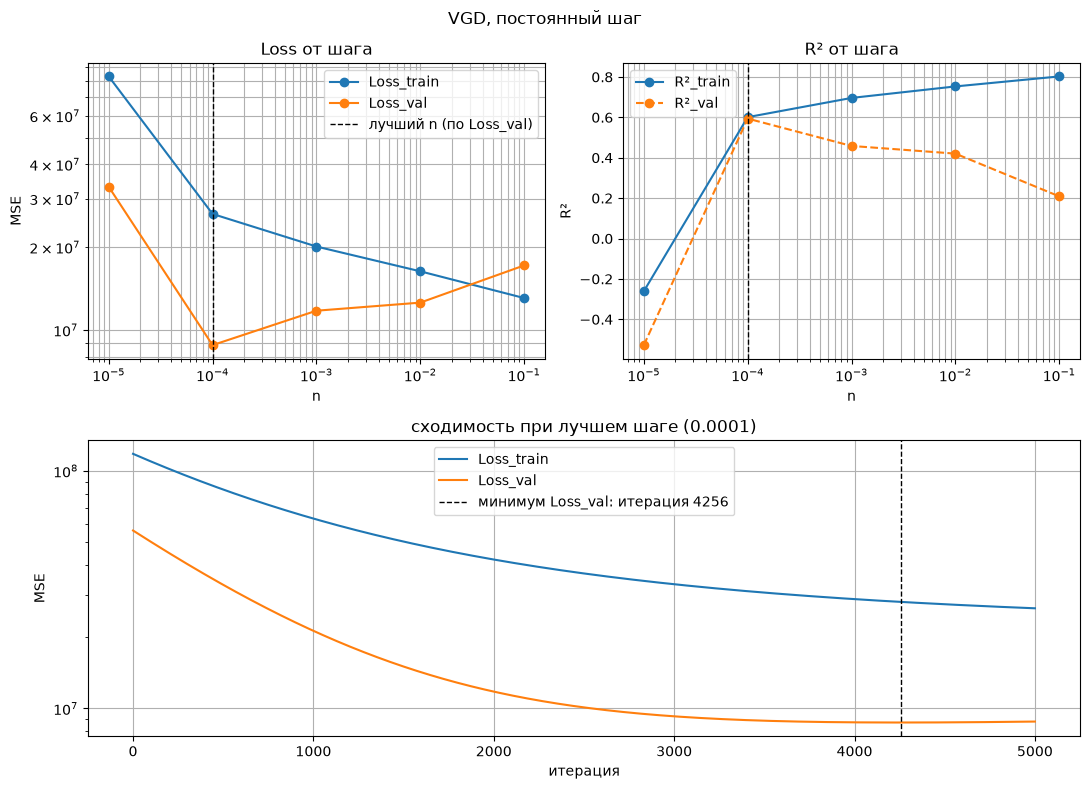

In [46]:
class VanillaGradientDescent(BaseLinearDescent):
    """Полный градиентный спуск: шаг по градиенту, посчитанному на всей train-выборке."""

    def _step(self, X: Array, y: Array, w: Array, k: int, rng: np.random.Generator) -> Array:
        return w - self._lr(k) * mse_gradient(X, y, w)


vgd_const_table, vgd_const_best = tune_step(
    VanillaGradientDescent,
    dataset,
    schedule="const",
    step_name="n",
)
print_best("VGD, постоянный шаг", vgd_const_table, vgd_const_best, "n", dataset)
plot_experiment(vgd_const_table, vgd_const_best, "n", "VGD, постоянный шаг")

5. Исследуйте VGD с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите VGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте VGD на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте VGD c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

  lyamda=1e-05: Loss_val=5.52e+07, R^2_val=-1.545, iter=5000
  lyamda=0.0001: Loss_val=4.81e+07, R^2_val=-1.216, iter=5000
  lyamda=0.001: Loss_val=1.6e+07, R^2_val=0.264, iter=5000
  lyamda=0.01: Loss_val=1.05e+07, R^2_val=0.517, iter=5000
  lyamda=0.1: Loss_val=1.21e+07, R^2_val=0.442, iter=5000
  lyamda=1: Loss_val=1.39e+07, R^2_val=0.358, iter=5000
VGD, TimeDecayLR
  лучший lyamda: 0.01
  Loss_train: 21993125.17
  R^2_train:  0.67
  Loss_val:   10477676.86
  R^2_val:    0.52
  Loss_test:  17789114.96
  R^2_test:   0.70
  итераций:   5000 (минимум Loss_val на итерации 482)


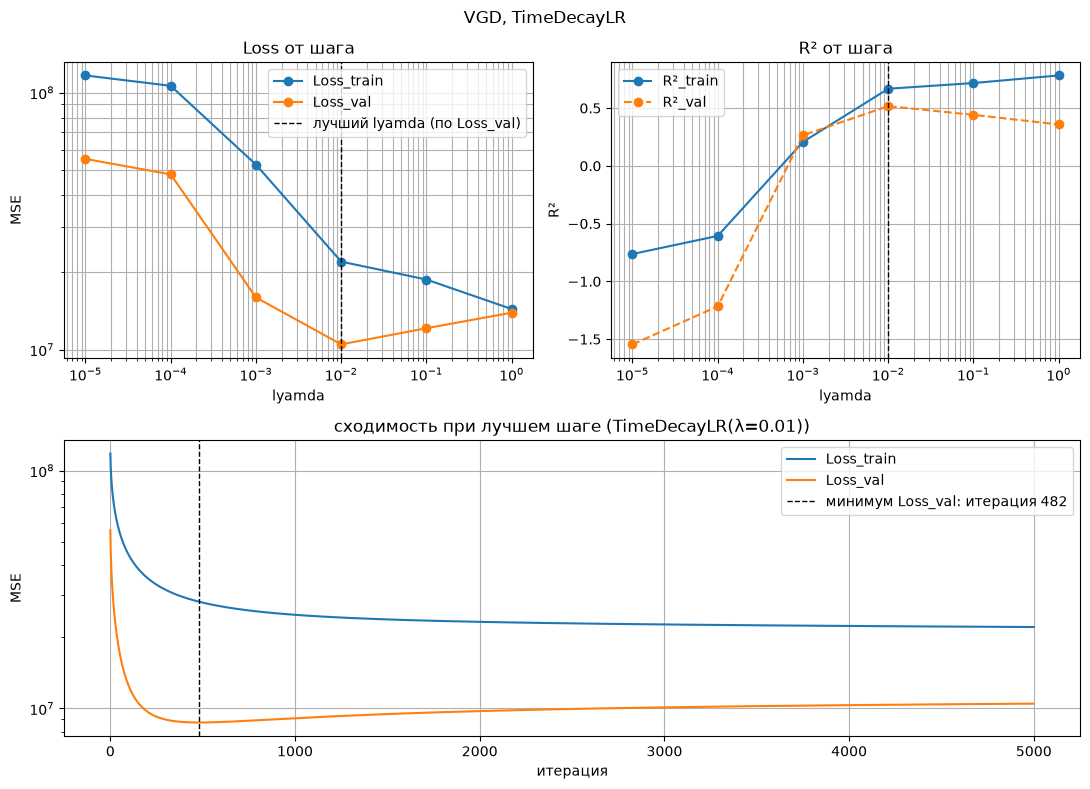

In [47]:
vgd_decay_table, vgd_decay_best = tune_step(
    VanillaGradientDescent,
    dataset,
    schedule="time_decay",
    step_name="lyamda",
)
print_best("VGD, TimeDecayLR", vgd_decay_table, vgd_decay_best, "lyamda", dataset)
plot_experiment(vgd_decay_table, vgd_decay_best, "lyamda", "VGD, TimeDecayLR")

6. Исследуйте SGD с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите SGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SGD на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SGD c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

  n=1e-05: Loss_val=3.32e+07, R^2_val=-0.530, iter=5000
  n=0.0001: Loss_val=8.77e+06, R^2_val=0.596, iter=5000
  n=0.001: Loss_val=1.16e+07, R^2_val=0.466, iter=5000
  n=0.01: Loss_val=1.25e+07, R^2_val=0.424, iter=5000
  n=0.1: Loss_val=1.65e+07, R^2_val=0.239, iter=5000
  n=1: Loss_val=inf, R^2_val=-inf, iter=197
SGD, постоянный шаг
  лучший n: 0.0001
  Loss_train: 26463872.94
  R^2_train:  0.60
  Loss_val:   8766229.85
  R^2_val:    0.60
  Loss_test:  22199529.31
  R^2_test:   0.63
  итераций:   5000 (минимум Loss_val на итерации 4238)


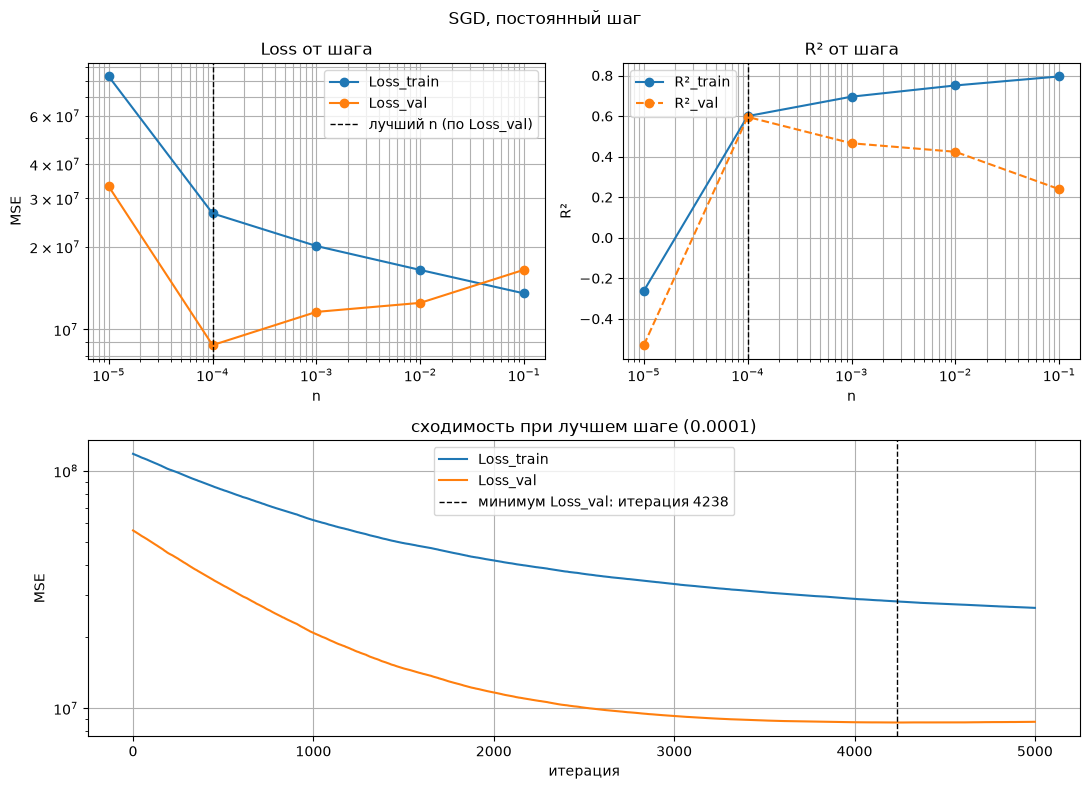

In [48]:
SGD_BATCH_SIZE = 32


class StochasticGradientDescent(BaseLinearDescent):
    """Стохастический градиентный спуск: градиент по случайному мини-батчу без повторов."""

    batch_size: int = SGD_BATCH_SIZE

    def _step(self, X: Array, y: Array, w: Array, k: int, rng: np.random.Generator) -> Array:
        batch = rng.choice(X.shape[0], size=self.batch_size, replace=False)
        return w - self._lr(k) * mse_gradient(X[batch], y[batch], w)


sgd_const_table, sgd_const_best = tune_step(
    StochasticGradientDescent,
    dataset,
    schedule="const",
    step_name="n",
)
print_best("SGD, постоянный шаг", sgd_const_table, sgd_const_best, "n", dataset)
plot_experiment(sgd_const_table, sgd_const_best, "n", "SGD, постоянный шаг")

7. Исследуйте SGD с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите SGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SGD на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SGD c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

  lyamda=1e-05: Loss_val=5.52e+07, R^2_val=-1.545, iter=5000
  lyamda=0.0001: Loss_val=4.8e+07, R^2_val=-1.216, iter=5000
  lyamda=0.001: Loss_val=1.59e+07, R^2_val=0.266, iter=5000
  lyamda=0.01: Loss_val=1.03e+07, R^2_val=0.523, iter=5000
  lyamda=0.1: Loss_val=1.2e+07, R^2_val=0.446, iter=5000
  lyamda=1: Loss_val=9.8e+08, R^2_val=-44.180, iter=5000
SGD, TimeDecayLR
  лучший lyamda: 0.01
  Loss_train: 22047653.29
  R^2_train:  0.67
  Loss_val:   10345983.77
  R^2_val:    0.52
  Loss_test:  17804990.02
  R^2_test:   0.70
  итераций:   5000 (минимум Loss_val на итерации 494)


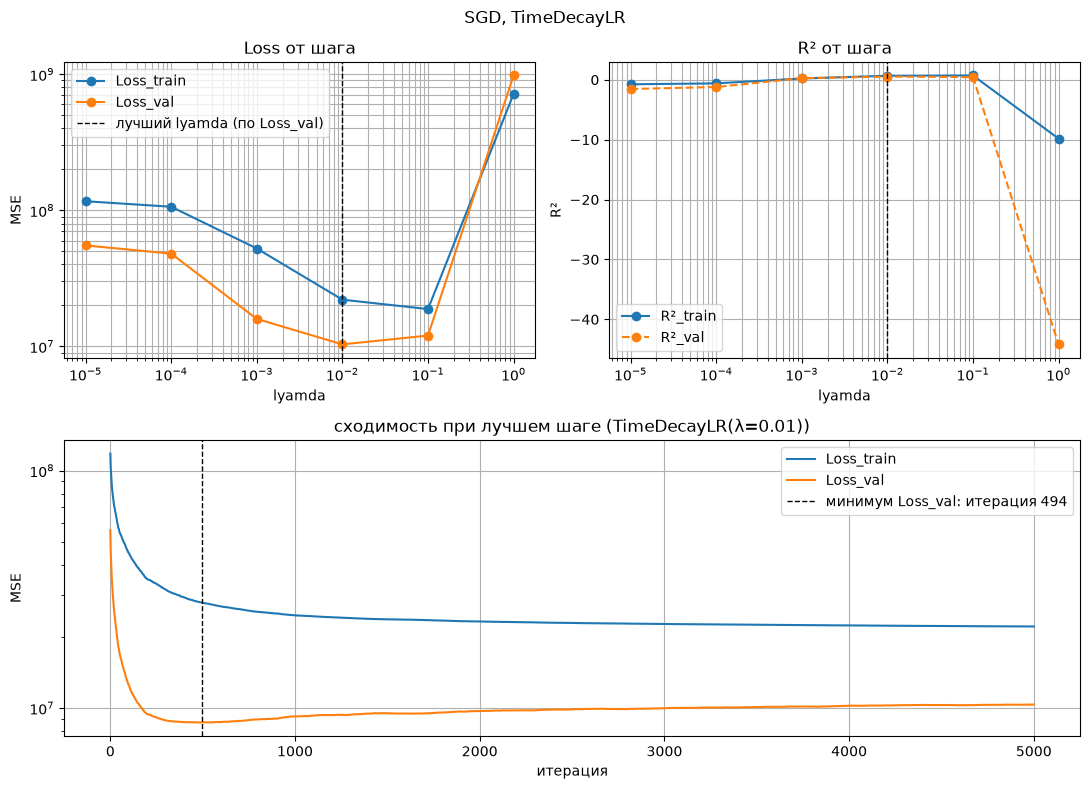

In [49]:
sgd_decay_table, sgd_decay_best = tune_step(
    StochasticGradientDescent,
    dataset,
    schedule="time_decay",
    step_name="lyamda",
)
print_best("SGD, TimeDecayLR", sgd_decay_table, sgd_decay_best, "lyamda", dataset)
plot_experiment(sgd_decay_table, sgd_decay_best, "lyamda", "SGD, TimeDecayLR")

8. Исследуйте SAG с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите SAG на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SAG на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SAG c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

  n=1e-05: Loss_val=3.53e+07, R^2_val=-0.629, iter=5000
  n=0.0001: Loss_val=9.96e+06, R^2_val=0.541, iter=5000
  n=0.001: Loss_val=1.32e+07, R^2_val=0.393, iter=5000
  n=0.01: Loss_val=1.14e+07, R^2_val=0.472, iter=5000
  n=0.1: Loss_val=7.01e+09, R^2_val=-322.437, iter=5000
  n=1: Loss_val=8.74e+34, R^2_val=-4028326465017771690840555520.000, iter=5000
SAG, постоянный шаг
  лучший n: 0.0001
  Loss_train: 26042773.92
  R^2_train:  0.61
  Loss_val:   9955187.20
  R^2_val:    0.54
  Loss_test:  21806879.09
  R^2_test:   0.64
  итераций:   5000 (минимум Loss_val на итерации 3490)


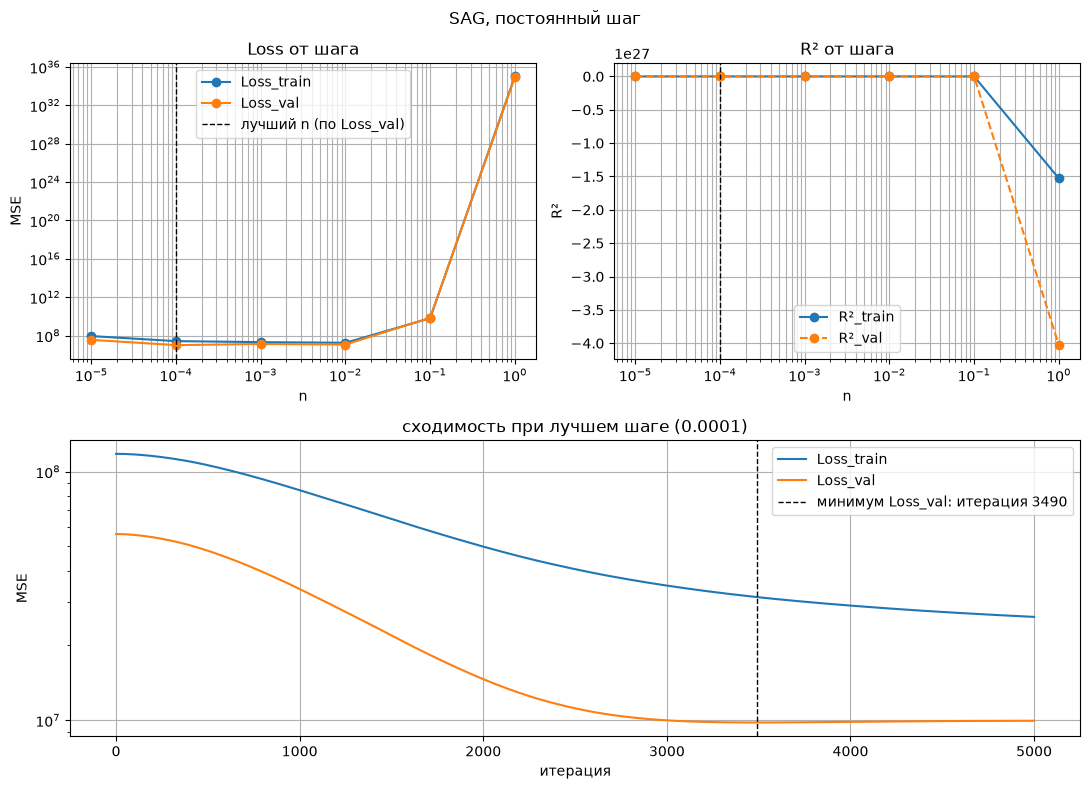

In [50]:
class SAGDescent(BaseLinearDescent):
    """SAG: на каждой итерации обновляем градиент одного случайного объекта.

    Храним последний известный остаток 2·(x_jᵀw − y_j) для каждого объекта и среднее
    градиентов `_mean_grad`; шаг делаем по этому среднему, пересчитывая его инкрементально.
    """

    _residuals: Array
    _mean_grad: Array

    def _init_state(self, n_samples: int, n_features: int) -> None:
        self._residuals = np.zeros(n_samples, dtype=np.float64)
        self._mean_grad = np.zeros(n_features, dtype=np.float64)

    def _step(self, X: Array, y: Array, w: Array, k: int, rng: np.random.Generator) -> Array:
        n_samples = X.shape[0]
        j = int(rng.integers(n_samples))
        residual = 2.0 * (float(X[j] @ w) - y[j])
        self._mean_grad = self._mean_grad + (residual - self._residuals[j]) / n_samples * X[j]
        self._residuals[j] = residual
        return w - self._lr(k) * self._mean_grad


sag_const_table, sag_const_best = tune_step(
    SAGDescent,
    dataset,
    schedule="const",
    step_name="n",
)
print_best("SAG, постоянный шаг", sag_const_table, sag_const_best, "n", dataset)
plot_experiment(sag_const_table, sag_const_best, "n", "SAG, постоянный шаг")

9. Исследуйте SAG с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите SAG на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SAG на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SAG c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

  lyamda=1e-05: Loss_val=5.55e+07, R^2_val=-1.559, iter=5000
  lyamda=0.0001: Loss_val=5.06e+07, R^2_val=-1.334, iter=5000
  lyamda=0.001: Loss_val=2.15e+07, R^2_val=0.009, iter=5000
  lyamda=0.01: Loss_val=1.11e+07, R^2_val=0.487, iter=5000
  lyamda=0.1: Loss_val=1.26e+07, R^2_val=0.419, iter=5000
  lyamda=1: Loss_val=1.56e+07, R^2_val=0.281, iter=5000
SAG, TimeDecayLR
  лучший lyamda: 0.01
  Loss_train: 22489716.95
  R^2_train:  0.66
  Loss_val:   11115715.26
  R^2_val:    0.49
  Loss_test:  17640460.01
  R^2_test:   0.71
  итераций:   5000 (минимум Loss_val на итерации 1047)


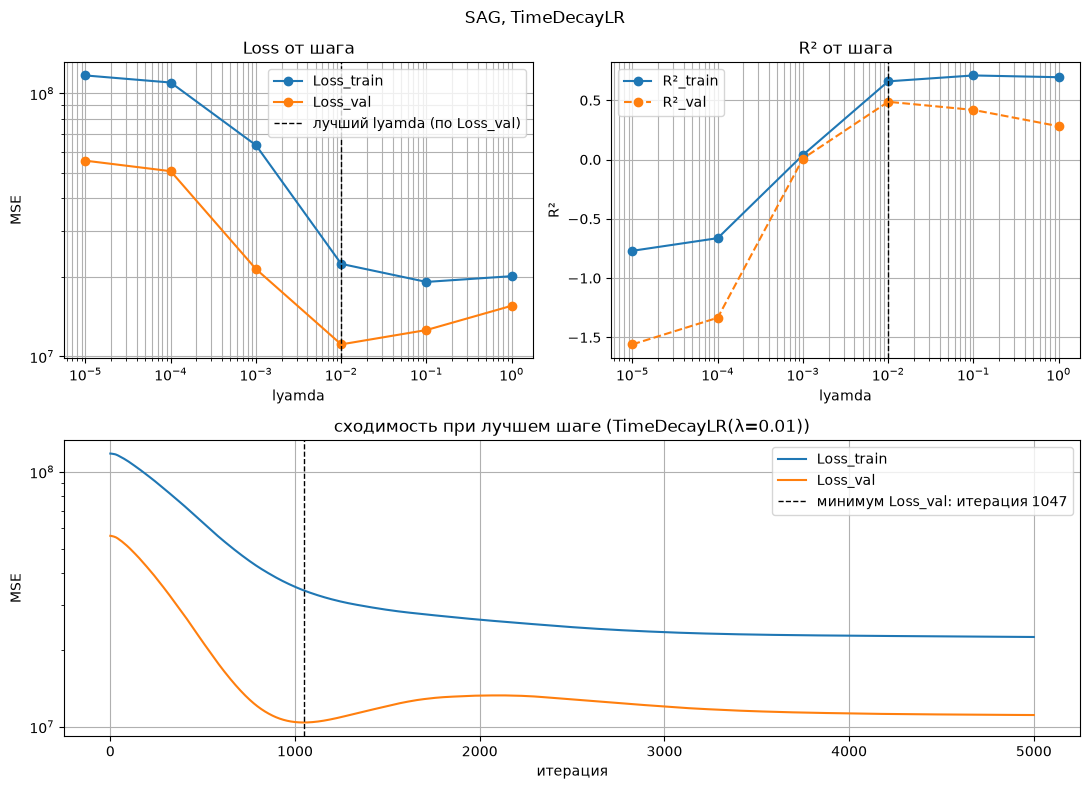

In [51]:
sag_decay_table, sag_decay_best = tune_step(
    SAGDescent,
    dataset,
    schedule="time_decay",
    step_name="lyamda",
)
print_best("SAG, TimeDecayLR", sag_decay_table, sag_decay_best, "lyamda", dataset)
plot_experiment(sag_decay_table, sag_decay_best, "lyamda", "SAG, TimeDecayLR")

10. Исследуйте Momentum с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите Momentum на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Momentum на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Momentum c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

  n=1e-05: Loss_val=8.81e+06, R^2_val=0.594, iter=5000
  n=0.0001: Loss_val=1.17e+07, R^2_val=0.458, iter=5000
  n=0.001: Loss_val=1.26e+07, R^2_val=0.420, iter=5000
  n=0.01: Loss_val=1.72e+07, R^2_val=0.209, iter=5000
  n=0.1: Loss_val=2.1e+07, R^2_val=0.032, iter=5000
  n=1: Loss_val=inf, R^2_val=-inf, iter=224
Momentum, постоянный шаг
  лучший n: 0.00001
  Loss_train: 26384703.48
  R^2_train:  0.60
  Loss_val:   8811620.73
  R^2_val:    0.59
  Loss_test:  22089880.23
  R^2_test:   0.63
  итераций:   5000 (минимум Loss_val на итерации 4252)


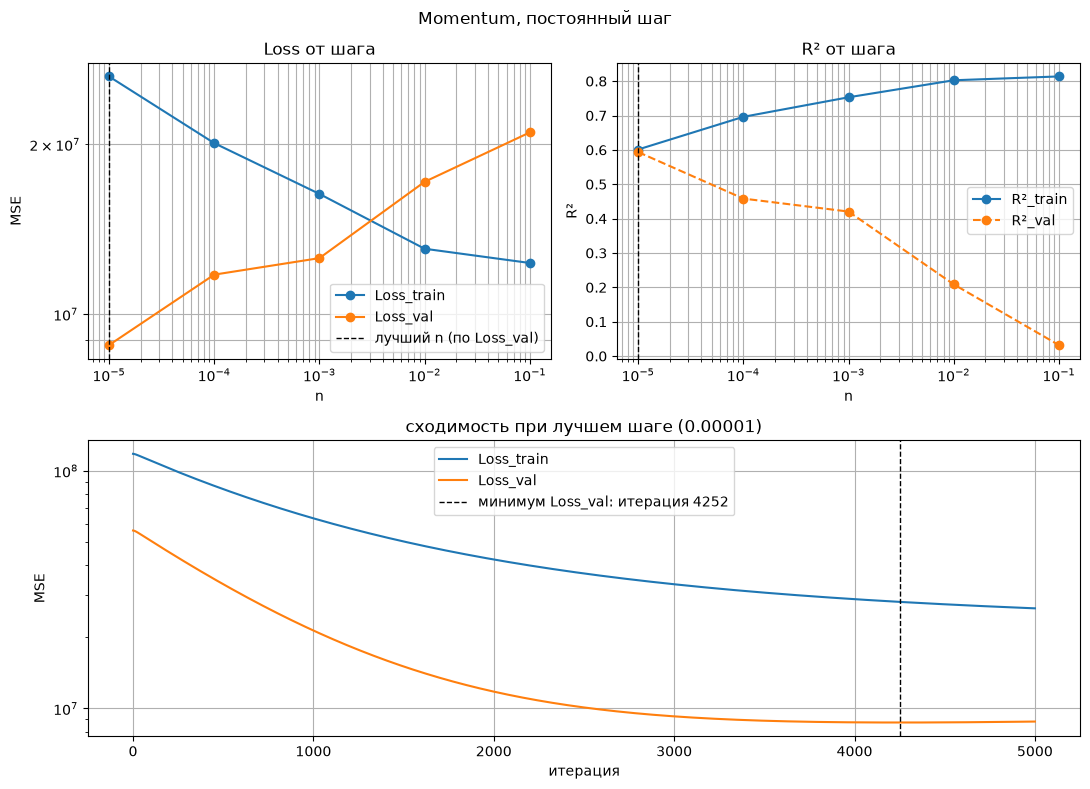

In [52]:
MOMENTUM_ALPHA = 0.9


class MomentumDescent(BaseLinearDescent):
    """Метод импульса: h_k = α·h_{k−1} + η_k·∇MSE, w_k = w_{k−1} − h_k."""

    alpha: float = MOMENTUM_ALPHA
    _momentum: Array

    def _init_state(self, n_samples: int, n_features: int) -> None:
        self._momentum = np.zeros(n_features, dtype=np.float64)

    def _step(self, X: Array, y: Array, w: Array, k: int, rng: np.random.Generator) -> Array:
        self._momentum = self.alpha * self._momentum + self._lr(k) * mse_gradient(X, y, w)
        return w - self._momentum


momentum_const_table, momentum_const_best = tune_step(
    MomentumDescent,
    dataset,
    schedule="const",
    step_name="n",
)
print_best("Momentum, постоянный шаг", momentum_const_table, momentum_const_best, "n", dataset)
plot_experiment(momentum_const_table, momentum_const_best, "n", "Momentum, постоянный шаг")

11. Исследуйте Momentum с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите Momentum на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Momentum на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Momentum c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

  lyamda=1e-05: Loss_val=4.81e+07, R^2_val=-1.216, iter=5000
  lyamda=0.0001: Loss_val=1.59e+07, R^2_val=0.265, iter=5000
  lyamda=0.001: Loss_val=1.05e+07, R^2_val=0.516, iter=5000
  lyamda=0.01: Loss_val=1.21e+07, R^2_val=0.442, iter=5000
  lyamda=0.1: Loss_val=1.39e+07, R^2_val=0.358, iter=5000
  lyamda=1: Loss_val=1.88e+07, R^2_val=0.135, iter=5000
Momentum, TimeDecayLR
  лучший lyamda: 0.001
  Loss_train: 21989508.24
  R^2_train:  0.67
  Loss_val:   10488838.47
  R^2_val:    0.52
  Loss_test:  17780745.89
  R^2_test:   0.70
  итераций:   5000 (минимум Loss_val на итерации 461)


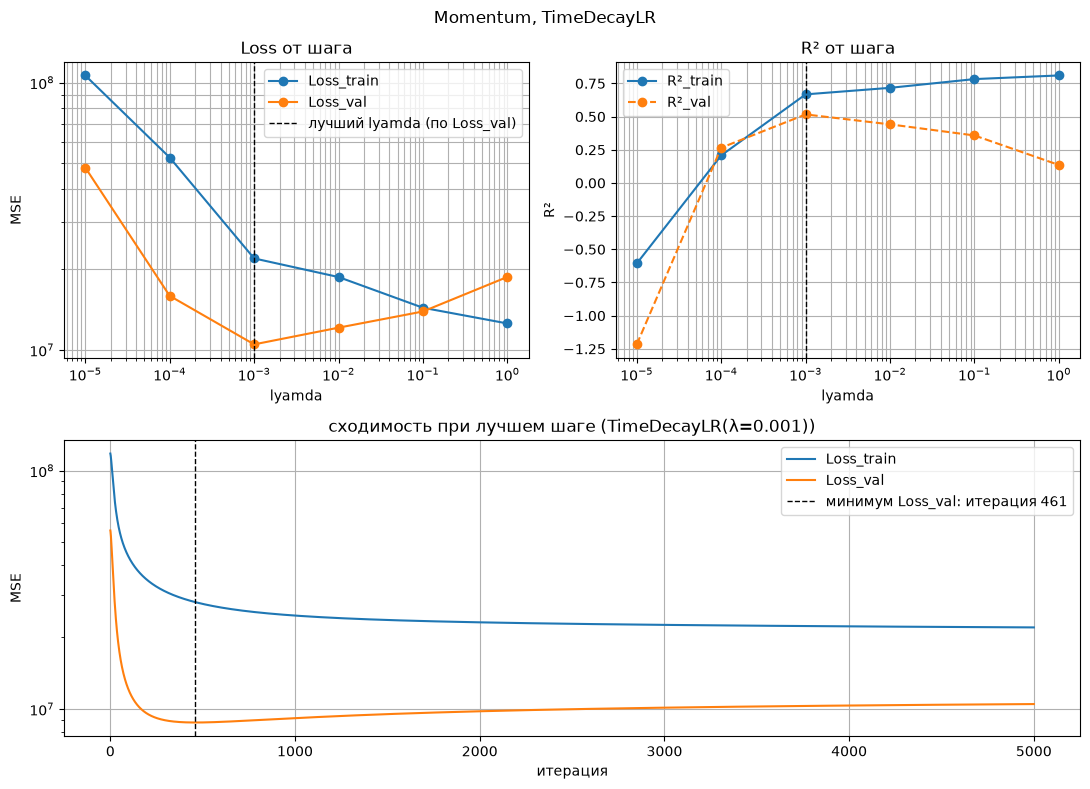

In [53]:
momentum_decay_table, momentum_decay_best = tune_step(
    MomentumDescent,
    dataset,
    schedule="time_decay",
    step_name="lyamda",
)
print_best("Momentum, TimeDecayLR", momentum_decay_table, momentum_decay_best, "lyamda", dataset)
plot_experiment(momentum_decay_table, momentum_decay_best, "lyamda", "Momentum, TimeDecayLR")

12. Исследуйте Adam с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите Adam на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Adam на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Adam c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

  n=1e-05: Loss_val=5.61e+07, R^2_val=-1.585, iter=5000
  n=0.0001: Loss_val=5.6e+07, R^2_val=-1.583, iter=5000
  n=0.001: Loss_val=5.56e+07, R^2_val=-1.565, iter=5000
  n=0.01: Loss_val=5.17e+07, R^2_val=-1.386, iter=5000
  n=0.1: Loss_val=2.49e+07, R^2_val=-0.148, iter=5000
  n=1: Loss_val=1.32e+07, R^2_val=0.392, iter=5000
Adam, постоянный шаг
  лучший n: 1
  Loss_train: 15576887.97
  R^2_train:  0.76
  Loss_val:   13187184.42
  R^2_val:    0.39
  Loss_test:  19062782.43
  R^2_test:   0.68
  итераций:   5000 (минимум Loss_val на итерации 2069)


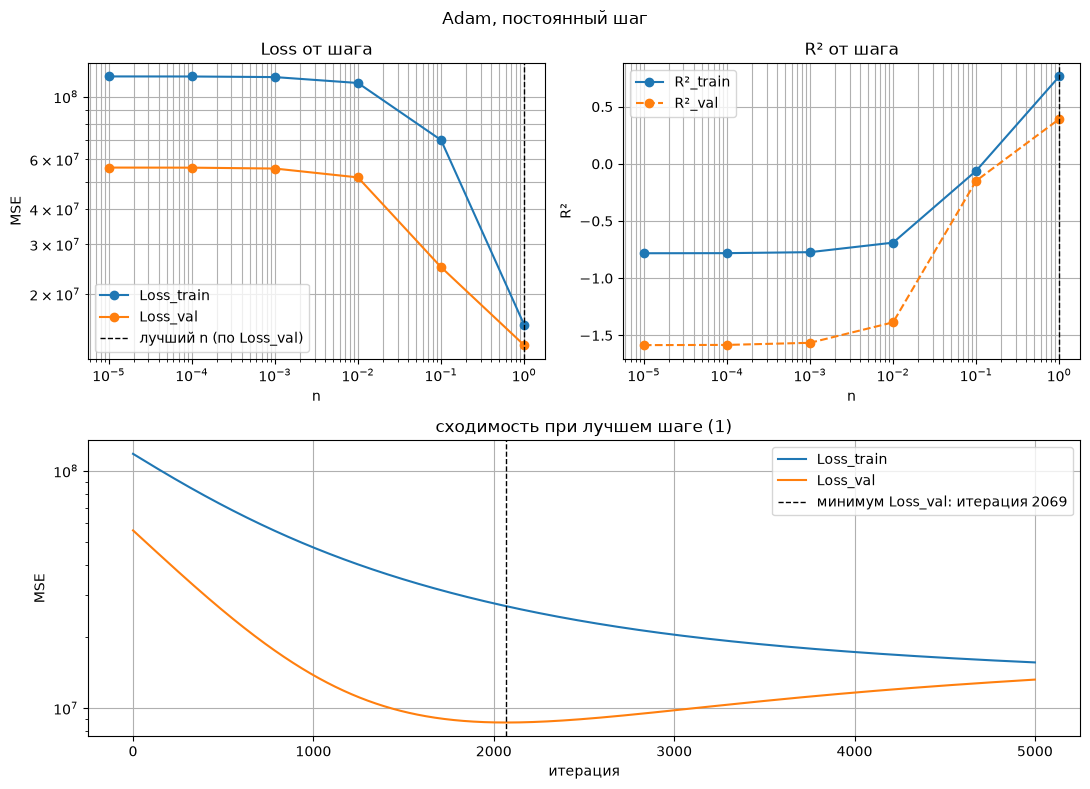

In [54]:
ADAM_BETA1 = 0.9
ADAM_BETA2 = 0.999
ADAM_EPS = 1e-8


class Adam(BaseLinearDescent):
    """Adam: m — экспоненциальное среднее градиента, v — его квадрата, с bias correction.

    m_k = β₁·m_{k−1} + (1 − β₁)·g_k,      m̂_k = m_k / (1 − β₁^k)
    v_k = β₂·v_{k−1} + (1 − β₂)·g_k²,     v̂_k = v_k / (1 − β₂^k)
    w_k = w_{k−1} − η_k · m̂_k / (√v̂_k + ε)

    Внутри `_step` итерации нумеруются с нуля, поэтому в поправках стоит k + 1.
    """

    beta1: float = ADAM_BETA1
    beta2: float = ADAM_BETA2
    eps: float = ADAM_EPS
    _m: Array
    _v: Array

    def _init_state(self, n_samples: int, n_features: int) -> None:
        self._m = np.zeros(n_features, dtype=np.float64)
        self._v = np.zeros(n_features, dtype=np.float64)

    def _step(self, X: Array, y: Array, w: Array, k: int, rng: np.random.Generator) -> Array:
        grad = mse_gradient(X, y, w)
        self._m = self.beta1 * self._m + (1.0 - self.beta1) * grad
        self._v = self.beta2 * self._v + (1.0 - self.beta2) * grad**2
        m_hat = self._m / (1.0 - self.beta1 ** (k + 1))
        v_hat = self._v / (1.0 - self.beta2 ** (k + 1))
        return w - self._lr(k) * m_hat / (np.sqrt(v_hat) + self.eps)


adam_const_table, adam_const_best = tune_step(
    Adam,
    dataset,
    schedule="const",
    step_name="n",
)
print_best("Adam, постоянный шаг", adam_const_table, adam_const_best, "n", dataset)
plot_experiment(adam_const_table, adam_const_best, "n", "Adam, постоянный шаг")

13. Исследуйте Adam с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите Adam на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Adam на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Adam c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

  lyamda=1e-05: Loss_val=5.61e+07, R^2_val=-1.585, iter=5000
  lyamda=0.0001: Loss_val=5.61e+07, R^2_val=-1.585, iter=5000
  lyamda=0.001: Loss_val=5.61e+07, R^2_val=-1.585, iter=5000
  lyamda=0.01: Loss_val=5.59e+07, R^2_val=-1.580, iter=5000
  lyamda=0.1: Loss_val=5.48e+07, R^2_val=-1.528, iter=5000
  lyamda=1: Loss_val=4.46e+07, R^2_val=-1.059, iter=5000
Adam, TimeDecayLR
  лучший lyamda: 1
  Loss_train: 101433388.46
  R^2_train:  -0.53
  Loss_val:   44647890.64
  R^2_val:    -1.06
  Loss_test:  96379499.46
  R^2_test:   -0.60
  итераций:   5000 (минимум Loss_val на итерации 5000)


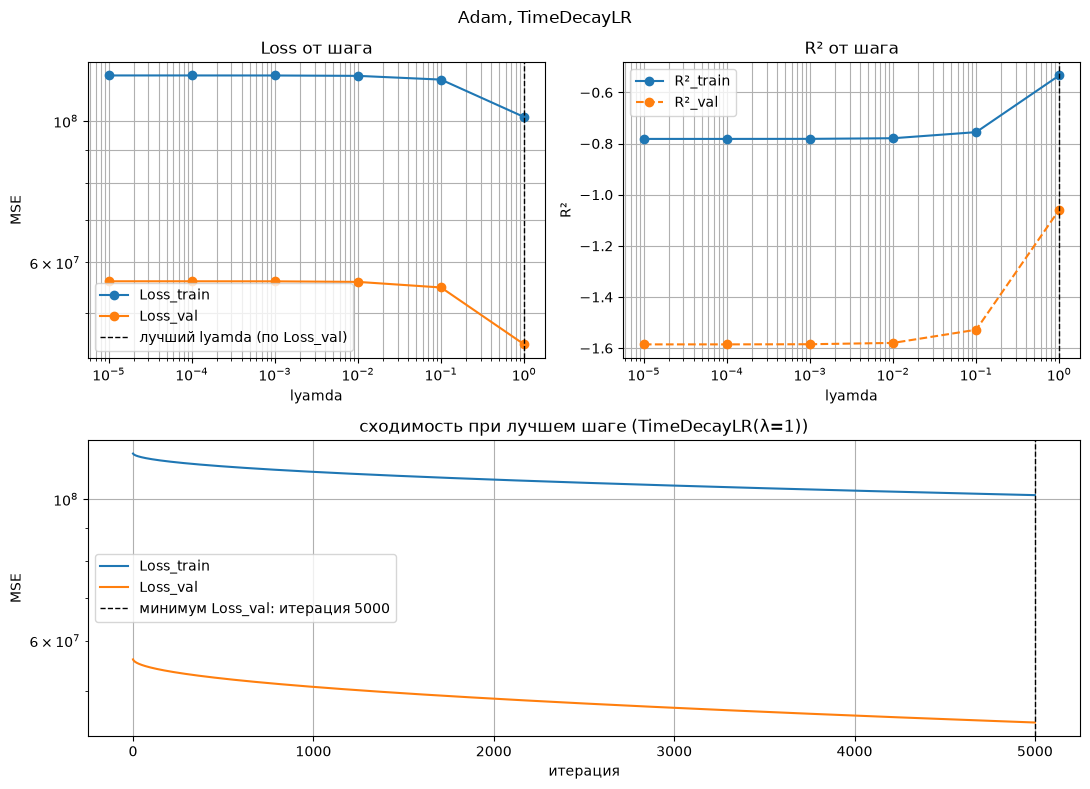

In [55]:
adam_decay_table, adam_decay_best = tune_step(
    Adam,
    dataset,
    schedule="time_decay",
    step_name="lyamda",
)
print_best("Adam, TimeDecayLR", adam_decay_table, adam_decay_best, "lyamda", dataset)
plot_experiment(adam_decay_table, adam_decay_best, "lyamda", "Adam, TimeDecayLR")

14. Постройте итоговую сравнительную таблицу со следующими столбцами:

1) название метода

2) значение лучшего шага (если n) или функция лучшего шага (если n(lyamda))

3) Loss_train

4) Loss_test

5) R^2 train

6) R^2 test

7) число итераций на test

In [56]:
best_models: dict[str, BaseLinearDescent] = {
    "VGD, n": vgd_const_best,
    "VGD, TimeDecayLR": vgd_decay_best,
    "SGD, n": sgd_const_best,
    "SGD, TimeDecayLR": sgd_decay_best,
    "SAG, n": sag_const_best,
    "SAG, TimeDecayLR": sag_decay_best,
    "Momentum, n": momentum_const_best,
    "Momentum, TimeDecayLR": momentum_decay_best,
    "Adam, n": adam_const_best,
    "Adam, TimeDecayLR": adam_decay_best,
}


def collect_row(name: str, model: BaseLinearDescent, dataset: Dataset) -> dict[str, object]:
    """Строка итоговой таблицы: шаг выбран по val, метрики на test считаются здесь один раз."""
    loss_train, r2_train = evaluate(dataset.X_train, dataset.y_train, model.weights)
    loss_test, r2_test = evaluate(dataset.X_test, dataset.y_test, model.weights)
    return {
        "метод": name,
        "шаг": model.step_label(),
        "Loss_train": loss_train,
        "Loss_test": loss_test,
        "R^2_train": r2_train,
        "R^2_test": r2_test,
        "итераций": model.n_iter_,
    }


def df_to_markdown(df: pd.DataFrame) -> str:
    """Markdown-таблица без tabulate (его нет в зависимостях проекта).

    MSE и R² округляются до двух знаков без научной записи.
    """
    headers = [str(col) for col in df.columns]

    def fmt(col: str, val: object) -> str:
        if col.startswith("Loss"):
            return f"{float(val):.2f}"
        if col.startswith("R^2"):
            return f"{float(val):.2f}"
        if isinstance(val, int | np.integer):
            return str(int(val))
        return str(val)

    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
    ]
    for _, row in df.iterrows():
        lines.append("| " + " | ".join(fmt(col, row[col]) for col in headers) + " |")
    return "\n".join(lines)


def plot_summary(summary: pd.DataFrame) -> None:
    """Столбчатое сравнение лучших моделей по test (значения берутся из готовой таблицы)."""
    labels = summary["метод"].tolist()
    r2_test = summary["R^2_test"].to_numpy(dtype=np.float64)
    loss_test = summary["Loss_test"].to_numpy(dtype=np.float64)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(labels, r2_test)
    axes[0].set_ylabel("R²_test")
    axes[0].set_title("R² на test")
    axes[0].tick_params(axis="x", rotation=70)
    axes[0].grid(True, axis="y")
    axes[1].bar(labels, np.where(np.isfinite(loss_test), loss_test, np.nan))
    axes[1].set_ylabel("MSE")
    axes[1].set_yscale("log")
    axes[1].set_title("Loss_test")
    axes[1].tick_params(axis="x", rotation=70)
    axes[1].grid(True, axis="y", which="both")
    fig.suptitle("Сравнение лучших моделей (шаг выбран по val, оценка на test)")
    fig.tight_layout()

| метод | шаг | Loss_train | Loss_test | R^2_train | R^2_test | итераций |
| --- | --- | --- | --- | --- | --- | --- |
| VGD, n | 0.0001 | 26390030.00 | 22096700.00 | 0.60 | 0.63 | 5000 |
| VGD, TimeDecayLR | TimeDecayLR(λ=0.01) | 21993130.00 | 17789110.00 | 0.67 | 0.70 | 5000 |
| SGD, n | 0.0001 | 26463870.00 | 22199530.00 | 0.60 | 0.63 | 5000 |
| SGD, TimeDecayLR | TimeDecayLR(λ=0.01) | 22047650.00 | 17804990.00 | 0.67 | 0.70 | 5000 |
| SAG, n | 0.0001 | 26042770.00 | 21806880.00 | 0.61 | 0.64 | 5000 |
| SAG, TimeDecayLR | TimeDecayLR(λ=0.01) | 22489720.00 | 17640460.00 | 0.66 | 0.71 | 5000 |
| Momentum, n | 0.00001 | 26384700.00 | 22089880.00 | 0.60 | 0.63 | 5000 |
| Momentum, TimeDecayLR | TimeDecayLR(λ=0.001) | 21989510.00 | 17780750.00 | 0.67 | 0.70 | 5000 |
| Adam, n | 1 | 15576890.00 | 19062780.00 | 0.76 | 0.68 | 5000 |
| Adam, TimeDecayLR | TimeDecayLR(λ=1) | 101433400.00 | 96379500.00 | -0.53 | -0.60 | 5000 |

15. Сделайте вывод о том, какой метод и шаг линейной регрессии самый лучший для данной выборки и ответьте на вопросы:

1) почему именно этот метод и этот шаг самый лучший (по каким данным из таблицы вы сделали такой вывод)

2) расскажите простыми словами суть R^2_train и R^2_test?

3) как R^2_train и R^2_test помогают сравнивать методы? почему оба эти значения надо вычислять для данного выбора?

**Лучший метод:** SAG, шаг `TimeDecayLR(λ=0.01)`.

**1)** У него в таблице самый маленький `Loss_test` и самый большой `R^2_test` (0.71). Adam лучше на train, но хуже на test — переобучился.

**2)** R² — насколько модель лучше предсказания «всегда среднее». Train — на обучении, test — на новых данных. 1 идеально, 0 как среднее, меньше 0 — хуже среднего.

**3)** MSE зависит от разброса цен, R² — нет. Оба R² нужны, чтобы увидеть переобучение: высокий train и низкий test.

**Почему у Adam + TimeDecayLR R² < 0.** Adam почти сам нормирует градиент, шаг слишком быстро падает, веса почти не сдвинулись с нуля. Модель хуже среднего — это недообучение, не взрыв.